# Google Play Store Market Analysis

**Author:** Donson Hoang
**Goal:** Analyze ~10,800 Google Play Store apps and 60k+ user reviews to
uncover what drives app ratings, installs, and pricing, and to practice a
full data-analyst workflow: data cleaning, exploratory data analysis, SQL
querying, and sentiment analysis.

**Tools:** Python, Jupyter, pandas, NumPy, Matplotlib, SQL (SQLite)

**Dataset:** [Google Play Store Apps](https://www.kaggle.com/datasets/lava18/google-play-store-apps) (Kaggle, CC BY 3.0)
- `googleplaystore.csv` — 10,841 apps x 13 attributes (category, rating, reviews, size, installs, price, etc.)
- `googleplaystore_user_reviews.csv` — 64,295 user reviews with pre-computed sentiment labels


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import sqlite3

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Libraries loaded.")

Libraries loaded.


## 1. Load the Data

In [2]:
apps = pd.read_csv('data/googleplaystore.csv')
reviews = pd.read_csv('data/googleplaystore_user_reviews.csv')

print(f"apps.csv:    {apps.shape[0]:,} rows x {apps.shape[1]} columns")
print(f"reviews.csv: {reviews.shape[0]:,} rows x {reviews.shape[1]} columns")
print()
print(apps.head(3))

apps.csv:    10,841 rows x 13 columns
reviews.csv: 64,295 rows x 5 columns

                                                 App        Category  Rating Reviews  Size    Installs  Type Price  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1     159   19M     10,000+  Free     0   
1                                Coloring book moana  ART_AND_DESIGN     3.9     967   14M    500,000+  Free     0   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   87510  8.7M  5,000,000+  Free     0   

  Content Rating                     Genres      Last Updated Current Ver   Android Ver  
0       Everyone               Art & Design   January 7, 2018       1.0.0  4.0.3 and up  
1       Everyone  Art & Design;Pretend Play  January 15, 2018       2.0.0  4.0.3 and up  
2       Everyone               Art & Design    August 1, 2018       1.2.4  4.0.3 and up  


## 2. Data Cleaning

Raw fields like `Installs` (`"10,000+"`), `Price` (`"$4.99"`), `Size`
(`"14M"` / `"Varies with device"`) and `Reviews` are stored as text and need
to be converted to numeric types before analysis. There is also one known
malformed row (a Category value of `"1.9"`, caused by a shifted column) that
must be dropped.

In [3]:
raw_rows = len(apps)

# Drop the known malformed row (Category == '1.9', a shifted-column record)
apps = apps[apps['Category'] != '1.9'].copy()

# Drop exact duplicate app entries, keeping the first occurrence
dupes = apps.duplicated(subset='App').sum()
apps = apps.drop_duplicates(subset='App', keep='first').copy()

print(f"Removed 1 malformed row and {dupes:,} duplicate app entries")
print(f"Rows: {raw_rows:,} -> {len(apps):,}")

Removed 1 malformed row and 1,181 duplicate app entries
Rows: 10,841 -> 9,659


In [4]:
def clean_installs(x):
    return int(str(x).replace('+', '').replace(',', ''))

def clean_price(x):
    return float(str(x).replace('$', ''))

def clean_size(x):
    x = str(x)
    if x == 'Varies with device':
        return np.nan
    if x.endswith('M'):
        return float(x[:-1])
    if x.endswith('k'):
        return float(x[:-1]) / 1024
    try:
        return float(x)
    except ValueError:
        return np.nan

apps['Installs'] = apps['Installs'].apply(clean_installs)
apps['Price'] = apps['Price'].apply(clean_price)
apps['Size_MB'] = apps['Size'].apply(clean_size)
apps['Reviews'] = apps['Reviews'].astype(int)
apps['Last Updated'] = pd.to_datetime(apps['Last Updated'], format='mixed')
apps['Category'] = apps['Category'].str.replace('_', ' ').str.title()

# A handful of ratings are impossibly > 5 due to source data errors
apps.loc[apps['Rating'] > 5, 'Rating'] = np.nan

apps = apps.dropna(subset=['Type']).copy()

print("Converted: Installs, Price, Reviews -> numeric | Size -> Size_MB | Last Updated -> datetime")
print(apps[['Installs', 'Price', 'Size_MB', 'Reviews']].dtypes)

Converted: Installs, Price, Reviews -> numeric | Size -> Size_MB | Last Updated -> datetime
Installs      int64
Price       float64
Size_MB     float64
Reviews       int64
dtype: object


In [5]:
null_summary = apps.isna().sum()
null_summary = null_summary[null_summary > 0].sort_values(ascending=False)
print("Remaining missing values:")
print(null_summary)
print(f"\nRating is missing for {apps['Rating'].isna().mean()*100:.1f}% of apps (left as NaN; excluded row-wise in rating-based analyses).")

Remaining missing values:
Rating         1462
Size_MB        1226
Current Ver       8
Android Ver       2
dtype: int64

Rating is missing for 15.1% of apps (left as NaN; excluded row-wise in rating-based analyses).


Save the cleaned dataset so it can be reused outside this notebook (e.g. loaded directly into a BI tool or SQL database).

In [6]:
apps.to_csv('data/cleaned_googleplaystore.csv', index=False)
print(f"Saved cleaned dataset: data/cleaned_googleplaystore.csv ({len(apps):,} rows x {apps.shape[1]} columns)")

Saved cleaned dataset: data/cleaned_googleplaystore.csv (9,658 rows x 14 columns)


## 3. Exploratory Data Analysis (pandas & NumPy)

In [7]:
print(apps[['Rating', 'Reviews', 'Installs', 'Price', 'Size_MB']].describe().round(2))

        Rating      Reviews      Installs    Price  Size_MB
count  8196.00      9658.00  9.658000e+03  9658.00  8432.00
mean      4.17    216614.99  7.778312e+06     1.10    20.39
std       0.54   1831413.06  5.376100e+07    16.85    21.83
min       1.00         0.00  0.000000e+00     0.00     0.01
25%       4.00        25.00  1.000000e+03     0.00     4.60
50%       4.30       967.00  1.000000e+05     0.00    12.00
75%       4.50     29408.00  1.000000e+06     0.00    28.00
max       5.00  78158306.00  1.000000e+09   400.00   100.00


Most common category: Family (1,831 apps)


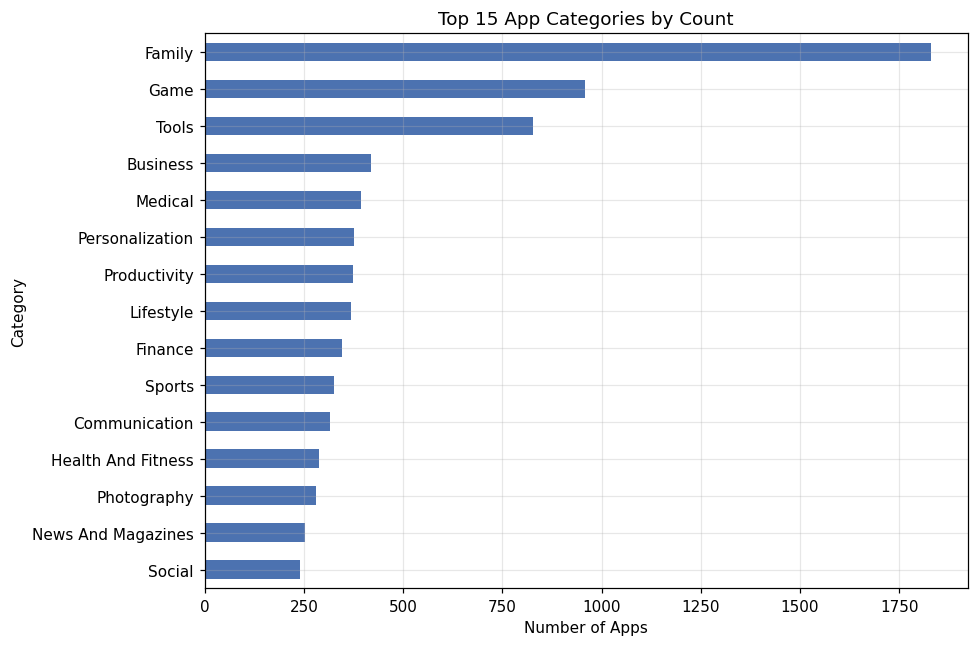

In [8]:
cat_counts = apps['Category'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
cat_counts.sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('Number of Apps')
ax.set_title('Top 15 App Categories by Count')
plt.tight_layout()
plt.show()

print(f"Most common category: {cat_counts.index[0]} ({cat_counts.iloc[0]:,} apps)")

92.2% of apps are Free, 7.8% are Paid


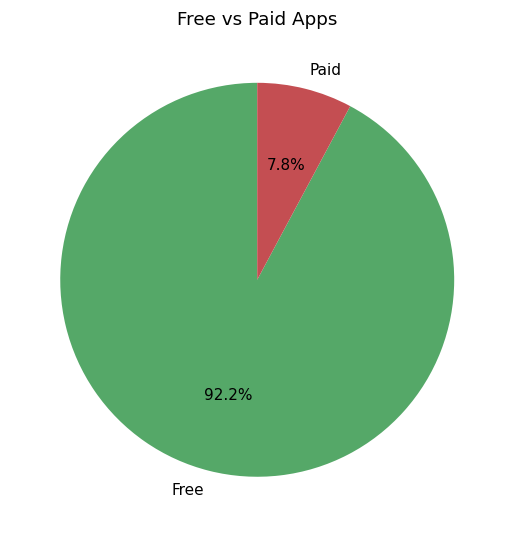

In [9]:
type_counts = apps['Type'].value_counts()
free_pct = type_counts['Free'] / type_counts.sum() * 100

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
       colors=['#55A868', '#C44E52'], startangle=90)
ax.set_title('Free vs Paid Apps')
plt.tight_layout()
plt.show()

print(f"{free_pct:.1f}% of apps are Free, {100-free_pct:.1f}% are Paid")

Mean rating: 4.17 | Median: 4.30 | Std: 0.54


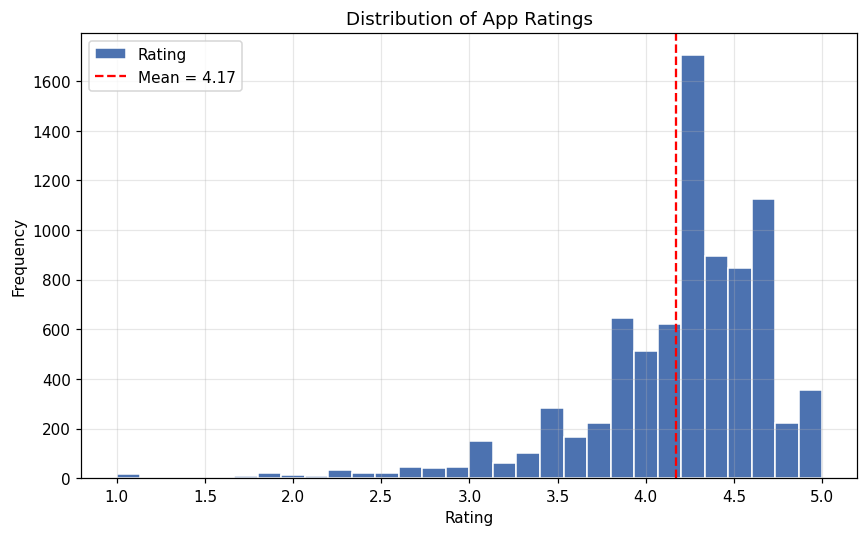

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
apps['Rating'].dropna().plot(kind='hist', bins=30, ax=ax, color='#4C72B0', edgecolor='white')
ax.axvline(apps['Rating'].mean(), color='red', linestyle='--', label=f"Mean = {apps['Rating'].mean():.2f}")
ax.set_xlabel('Rating')
ax.set_title('Distribution of App Ratings')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean rating: {apps['Rating'].mean():.2f} | Median: {apps['Rating'].median():.2f} | Std: {apps['Rating'].std():.2f}")

          Rating  Reviews  Installs  Price  Size_MB
Rating      1.00     0.06      0.04  -0.02     0.06
Reviews     0.06     1.00      0.63  -0.01     0.18
Installs    0.04     0.63      1.00  -0.01     0.13
Price      -0.02    -0.01     -0.01   1.00    -0.02
Size_MB     0.06     0.18      0.13  -0.02     1.00


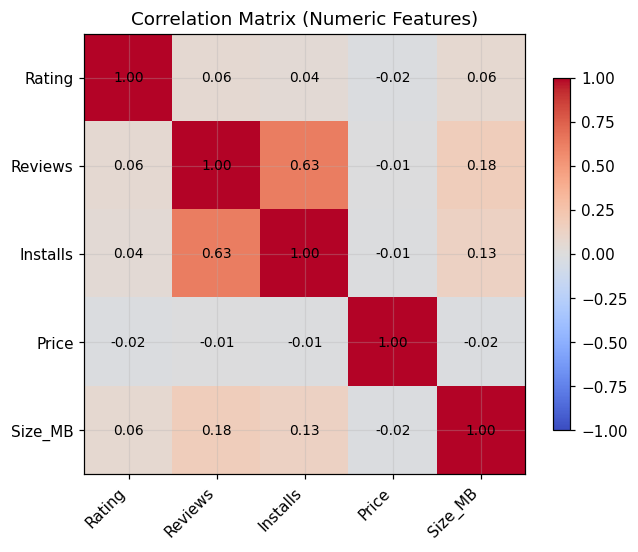

In [11]:
num_cols = ['Rating', 'Reviews', 'Installs', 'Price', 'Size_MB']
corr = apps[num_cols].corr(numeric_only=True)
print(corr.round(2))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', color='black', fontsize=9)
ax.set_title('Correlation Matrix (Numeric Features)')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 4. SQL Analysis

The cleaned DataFrame is loaded into an in-memory SQLite database so the
same questions can be answered with SQL — useful for demonstrating
query-writing skills and for portability into a real analytics database.

In [12]:
conn = sqlite3.connect(':memory:')
apps.to_sql('apps', conn, index=False, if_exists='replace')
print("Loaded 'apps' table into SQLite:", pd.read_sql("SELECT COUNT(*) AS n_rows FROM apps", conn).iloc[0, 0], "rows")

Loaded 'apps' table into SQLite: 9658 rows


In [13]:
q1 = '''
SELECT Category, COUNT(*) AS num_apps
FROM apps
GROUP BY Category
ORDER BY num_apps DESC
LIMIT 10;
'''
top_cats = pd.read_sql(q1, conn)
print(top_cats)

          Category  num_apps
0           Family      1831
1             Game       959
2            Tools       827
3         Business       420
4          Medical       395
5  Personalization       376
6     Productivity       374
7        Lifestyle       369
8          Finance       345
9           Sports       325


              Category  avg_rating  num_apps
0               Events        4.44        45
1            Education        4.36       118
2       Art And Design        4.36        61
3  Books And Reference        4.34       169
4      Personalization        4.33       298
5            Parenting        4.30        50
6               Beauty        4.28        42
7               Social        4.25       203
8                 Game        4.25       912
9              Weather        4.24        72


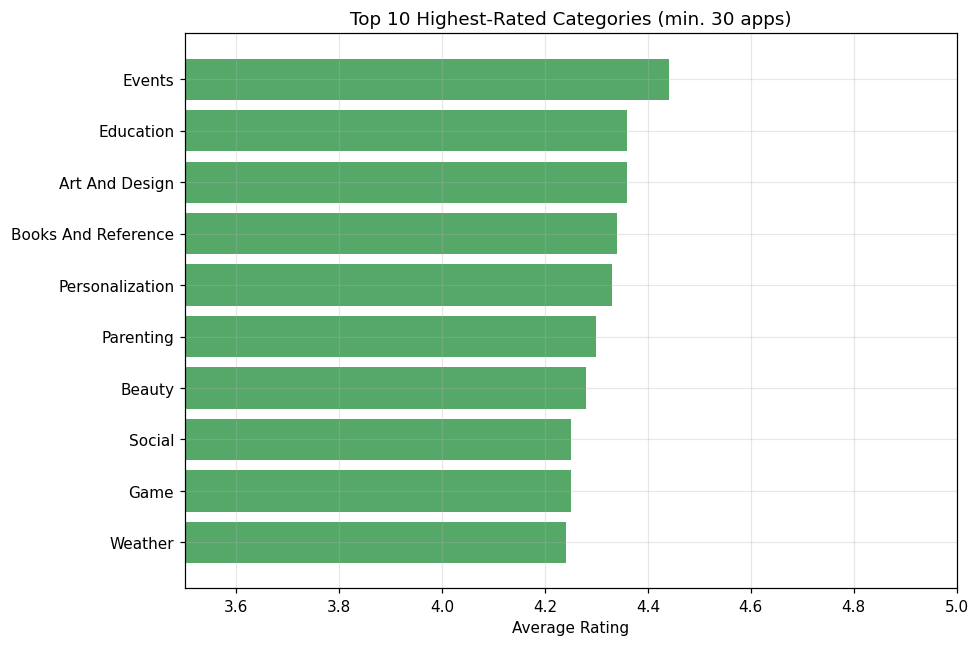

In [14]:
q2 = '''
SELECT Category,
       ROUND(AVG(Rating), 2) AS avg_rating,
       COUNT(*) AS num_apps
FROM apps
WHERE Rating IS NOT NULL
GROUP BY Category
HAVING COUNT(*) >= 30
ORDER BY avg_rating DESC
LIMIT 10;
'''
top_rated_cats = pd.read_sql(q2, conn)
print(top_rated_cats)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_rated_cats['Category'][::-1], top_rated_cats['avg_rating'][::-1], color='#55A868')
ax.set_xlim(3.5, 5)
ax.set_xlabel('Average Rating')
ax.set_title('Top 10 Highest-Rated Categories (min. 30 apps)')
plt.tight_layout()
plt.show()

In [15]:
q3 = '''
SELECT App, Category, Installs, Rating
FROM apps
ORDER BY Installs DESC
LIMIT 10;
'''
print(pd.read_sql(q3, conn).to_string(index=False))

                                     App            Category   Installs  Rating
                       Google Play Books Books And Reference 1000000000     3.9
Messenger – Text and Video Chat for Free       Communication 1000000000     4.0
                      WhatsApp Messenger       Communication 1000000000     4.4
            Google Chrome: Fast & Secure       Communication 1000000000     4.3
                                   Gmail       Communication 1000000000     4.3
                                Hangouts       Communication 1000000000     4.0
           Skype - free IM & video calls       Communication 1000000000     4.1
                       Google Play Games       Entertainment 1000000000     4.3
                          Subway Surfers                Game 1000000000     4.5
                                Facebook              Social 1000000000     4.1


In [16]:
q4 = '''
SELECT Type,
       ROUND(AVG(Rating), 2)   AS avg_rating,
       ROUND(AVG(Reviews), 0)  AS avg_reviews,
       ROUND(AVG(Installs), 0) AS avg_installs
FROM apps
GROUP BY Type;
'''
print(pd.read_sql(q4, conn))

   Type  avg_rating  avg_reviews  avg_installs
0  Free        4.17     234270.0     8432439.0
1  Paid        4.26       8725.0       75879.0


             Category  total_installs
0                Game     13878924415
1       Communication     11038276251
2               Tools      8001771915
3        Productivity      5793091369
4              Social      5487867902
5         Photography      4649147655
6              Family      4427941505
7       Video Players      3926902720
8    Travel And Local      2894887146
9  News And Magazines      2369217760


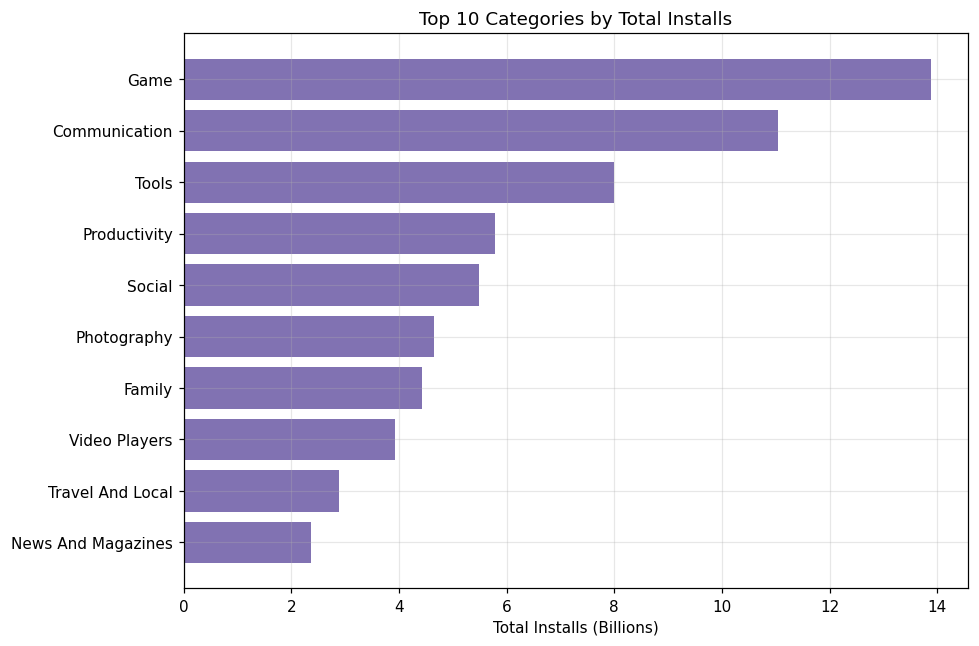

In [17]:
q5 = '''
SELECT Category, SUM(Installs) AS total_installs
FROM apps
GROUP BY Category
ORDER BY total_installs DESC
LIMIT 10;
'''
top_installs = pd.read_sql(q5, conn)
top_installs['total_installs_B'] = top_installs['total_installs'] / 1e9
print(top_installs[['Category', 'total_installs']])

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_installs['Category'][::-1], top_installs['total_installs_B'][::-1], color='#8172B2')
ax.set_xlabel('Total Installs (Billions)')
ax.set_title('Top 10 Categories by Total Installs')
plt.tight_layout()
plt.show()

## 5. User Review Sentiment Analysis

Sentiment
Positive    23998
Negative     8271
Neutral      5158
Name: count, dtype: int64

37,427 labeled reviews across 865 apps


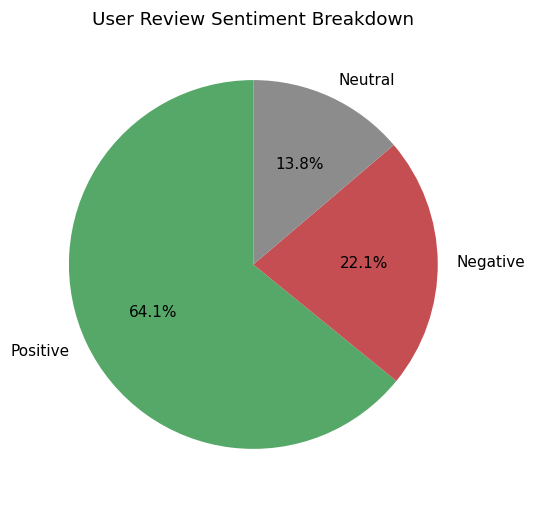

In [18]:
reviews_clean = reviews.dropna(subset=['Translated_Review', 'Sentiment']).copy()
sent_counts = reviews_clean['Sentiment'].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(sent_counts, labels=sent_counts.index, autopct='%1.1f%%',
       colors=['#55A868', '#C44E52', '#8C8C8C'], startangle=90)
ax.set_title('User Review Sentiment Breakdown')
plt.tight_layout()
plt.show()

print(sent_counts)
print(f"\n{len(reviews_clean):,} labeled reviews across {reviews_clean['App'].nunique():,} apps")

In [19]:
app_sentiment = reviews_clean.groupby('App', as_index=False)['Sentiment_Polarity'].mean()
app_sentiment = app_sentiment.rename(columns={'Sentiment_Polarity': 'Avg_Sentiment_Polarity'})

merged = apps.merge(app_sentiment, on='App', how='inner')
print(f"Matched {len(merged):,} apps between the ratings dataset and the reviews dataset")
print(merged[['App', 'Category', 'Rating', 'Avg_Sentiment_Polarity']].head())

Matched 816 apps between the ratings dataset and the reviews dataset
                                         App        Category  Rating  Avg_Sentiment_Polarity
0                        Coloring book moana  Art And Design     3.9                0.152652
1                       Garden Coloring Book  Art And Design     4.4                0.268483
2              FlipaClip - Cartoon animation  Art And Design     4.3                0.412649
3  Boys Photo Editor - Six Pack & Men's Suit  Art And Design     4.1                0.283509
4              Colorfit - Drawing & Coloring  Art And Design     4.7                0.171836


Correlation between average review sentiment and app rating: 0.264


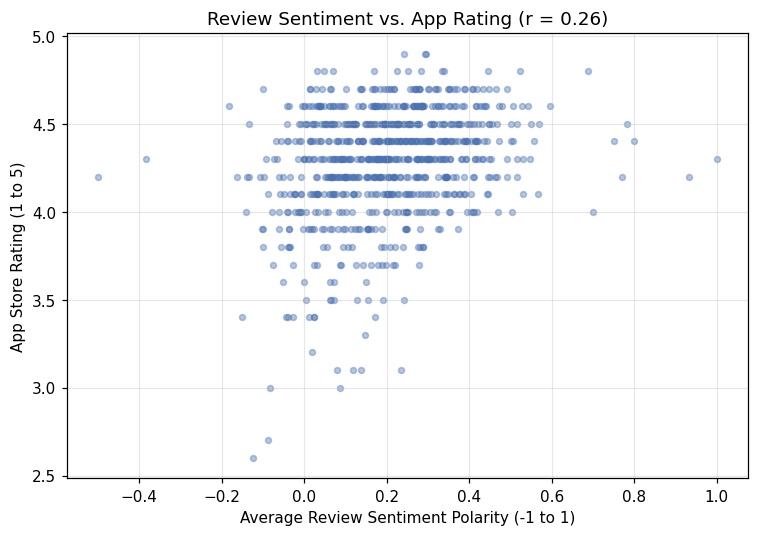

In [20]:
valid = merged.dropna(subset=['Rating', 'Avg_Sentiment_Polarity'])
sent_rating_corr = valid['Rating'].corr(valid['Avg_Sentiment_Polarity'])
print(f"Correlation between average review sentiment and app rating: {sent_rating_corr:.3f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(valid['Avg_Sentiment_Polarity'], valid['Rating'], alpha=0.4, s=15, color='#4C72B0')
ax.set_xlabel('Average Review Sentiment Polarity (-1 to 1)')
ax.set_ylabel('App Store Rating (1 to 5)')
ax.set_title(f'Review Sentiment vs. App Rating (r = {sent_rating_corr:.2f})')
plt.tight_layout()
plt.show()

                      mean  count
Category                         
Events               0.385      5
Maps And Navigation  0.322      7
Parenting            0.313      8
Health And Fitness   0.312     40
Education            0.305     22
Weather              0.298      6
Personalization      0.275     34
Auto And Vehicles    0.271      8
Food And Drink       0.265     18
Books And Reference  0.263     16


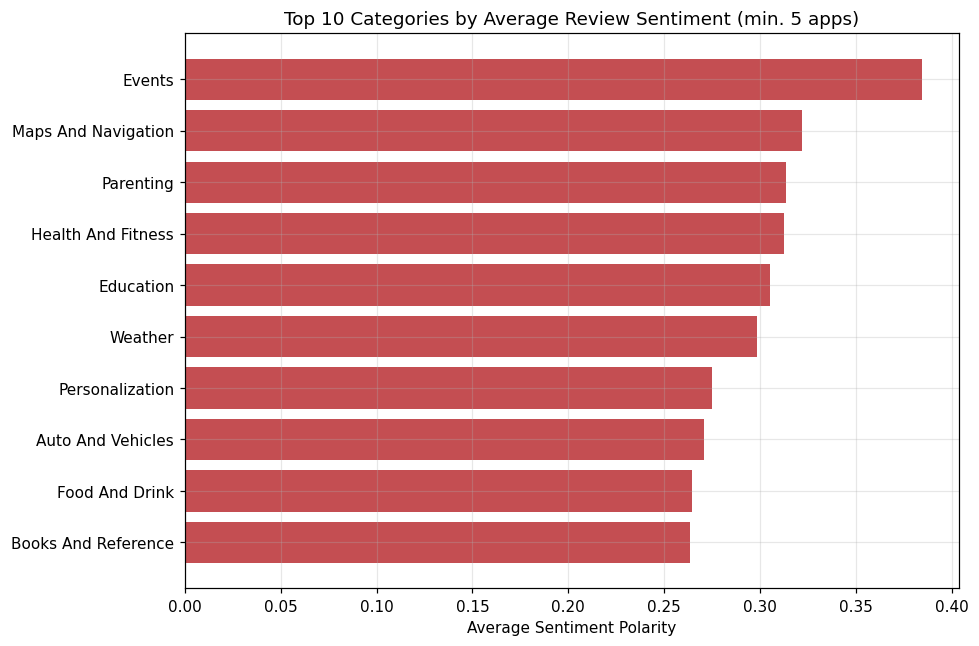

In [21]:
cat_sentiment = (merged.dropna(subset=['Avg_Sentiment_Polarity'])
                  .groupby('Category')['Avg_Sentiment_Polarity']
                  .agg(['mean', 'count']))
cat_sentiment = cat_sentiment[cat_sentiment['count'] >= 5].sort_values('mean', ascending=False).head(10)
print(cat_sentiment.round(3))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(cat_sentiment.index[::-1], cat_sentiment['mean'][::-1], color='#C44E52')
ax.set_xlabel('Average Sentiment Polarity')
ax.set_title('Top 10 Categories by Average Review Sentiment (min. 5 apps)')
plt.tight_layout()
plt.show()

## 6. Key Insights

- **Dataset:** 9,658 unique apps after cleaning (duplicates and a malformed row removed).
- **Free vs. Paid:** 92.2% of apps are free. Free apps average a rating of 4.17 and 234,270 reviews, vs. 4.26 rating and 8,725 reviews for paid apps — free apps get far more engagement, with similar average ratings.
- **Category volume:** **Family** is the most saturated category with 1,831 apps, but **Game** leads in total reach with **13.9 billion** cumulative installs.
- **Ratings:** the average app rating is 4.17/5 (median 4.30), and ratings skew right — most apps cluster between 4.0 and 4.5. **Events** has the highest average rating (4.44) among categories with 30+ apps.
- **Scale leader:** **Google Play Books** tops the install count at **1.0B** installs.
- **Sentiment vs. rating:** across 816 apps with review text, average user-review sentiment polarity correlates with the star rating at r = 0.26 — a weak-to-moderate positive relationship, meaning star ratings and review text sentiment are related but far from interchangeable.
- **Best-perceived category:** **Events** has the highest average review sentiment polarity (0.38) among categories with 5+ apps.


## 7. Conclusion & Next Steps

This project walked through a complete data-analyst workflow on real-world,
messy app-store data: cleaning inconsistent text fields into usable numeric
types, exploring distributions and relationships with pandas/NumPy/Matplotlib,
answering business questions with SQL, and layering in NLP-adjacent sentiment
data to connect qualitative user feedback to quantitative ratings.

**Possible extensions:**
- Build a regression/classification model to predict app rating from category, price, size, and installs.
- Run proper NLP (TF-IDF / topic modeling) on the raw review text rather than relying on pre-labeled sentiment.
- Track rating and install trends over time using the `Last Updated` field.
- Turn the SQL queries into a small dashboard (e.g. with Plotly Dash or Tableau) for interactive exploration.
